# Regresión logística

In [1]:
from datetime import datetime
from scipy.sparse import load_npz, hstack
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Carga del dataset

Se cargan los conjuntos de entrenamiento y prueba preprocesados del EDA, compuestos por:
* **Características TF-IDF:** Vectores de alta dimensionalidad derivados del cuerpo del correo (`TfidfVectorizer`).
* **Características adicionales:** Atributos lingüísticos extraídos durante el análisis exploratorio (tales como presencia de links, indicadores de urgencia, densidad de pronombres y verbos imperativos).

In [2]:
X_train = load_npz('datasets/X_train.npz')
X_extra_train = pd.read_csv('datasets/X_extra_train.csv')
X_test = load_npz('datasets/X_test.npz')
X_extra_test = pd.read_csv('datasets/X_extra_test.csv')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

X_extra_train.drop(['Email Text Raw'], axis=1, inplace=True)
X_extra_test.drop(['Email Text Raw'], axis=1, inplace=True)

## Preprocesamiento y Transformación

Para que el modelo de Regresión Logística procese adecuadamente tanto la matriz dispersa como las variables tabulares, se aplica un pipeline de transformación coordinado por `ColumnTransformer`:

* **StandardScaler (con `with_mean=False`):** Aplicado sobre todos los atributos, la matriz TF-IDF y sobre los adicionales. Esto asegura que todas las variables unifiquen su varianza, sin alterar la densidad de la matriz TF-IDF.
* **OneHotEncoder:** Aplicado sobre las variables categóricas, eliminando la primera categoría (`drop='first'`) para evitar multicolinealidad.
* **passthrough:** Preserva las variables binarias preexistentes (`has_link`, `domain_dot_high`, `has_suspicious_tags`).

In [3]:
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
scaler_num = StandardScaler(with_mean=False)
scaler_tfidf = StandardScaler(with_mean=False)

tf = ColumnTransformer(transformers=[
    ('bin', 'passthrough', ['has_link', 'domain_dot_high', 'has_suspicious_tags']),
    ('cat', ohe, ['words_count_cat']),
    ('num', scaler_num, ['imperative_verbs_count', 'pronoun_density', 'urgency_markers_count'])
],
remainder='drop')

X_train = scaler_tfidf.fit_transform(X_train)
X_test = scaler_tfidf.transform(X_test)

X_extra_train = tf.fit_transform(X_extra_train)
X_extra_test = tf.transform(X_extra_test)

X_train = hstack([X_train, X_extra_train])
X_test = hstack([X_test, X_extra_test])

## Modelo de Regresión Logística

Se entrena un modelo de clasificación lineal `LogisticRegression`. Este algoritmo modela la probabilidad de que una observación pertenezca a la clase positiva (phishing, `y=1`) mediante la función sigmoide

Para la optimización numérica se utiliza el solver `liblinear`, recomendado para este tipo de datasets con matrices dispersas de alta dimensionalidad y problemas de clasificación binaria.

In [4]:
logreg_model = LogisticRegression(max_iter=1000, solver='liblinear')

start_train = datetime.now()
logreg_model.fit(X_train, y_train)
train_duration = datetime.now() - start_train

start_pred = datetime.now()
y_pred = logreg_model.predict(X_test)
predict_duration = datetime.now() - start_pred

## Evaluación del Modelo

Se evalúa el desempeño del modelo mediante una matriz de confusión y métricas de clasificación. Dado que hay cierto desbalance de clases en el problema (aproximadamente 38% de correos son phishing), se utiliza la exactitud balanceada.

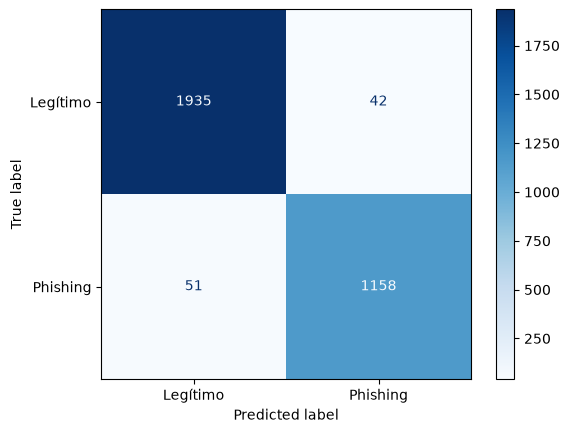

In [5]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [6]:
cm_logreg = confusion_matrix(y_test, y_pred)
P = cm_logreg[1, :].sum()
N = cm_logreg[0, :].sum()
TP = cm_logreg[1, 1]
TN = cm_logreg[0, 0]

TPR_logreg = TP / P
TNR_logreg = TN / N
balanced_accuracy_logreg = (TPR_logreg + TNR_logreg) / 2

precision_logreg = precision_score(y_test, y_pred, zero_division=0)
recall_logreg = recall_score(y_test, y_pred, zero_division=0)
f1_logreg = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_logreg:.4f}")
print(f"Precisión:               {precision_logreg:.4f}")
print(f"Sensibilidad (Recall):   {TPR_logreg:.4f}")
print(f"F1-score:                {f1_logreg:.4f}")
print(f"Especificidad:           {TNR_logreg:.4f}")
print(f"Recuperación (Recall):   {recall_logreg:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.9683
Precisión:               0.9650
Sensibilidad (Recall):   0.9578
F1-score:                0.9614
Especificidad:           0.9788
Recuperación (Recall):   0.9578
Tiempo de entrenamiento: 0:00:00.409886
Tiempo de predicción:    0:00:00.008256


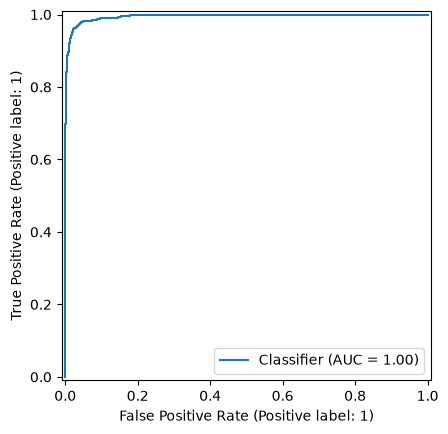

In [7]:
y_scores = logreg_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

## Análisis de Resultados y Conclusiones

La Regresión Logística muestra un desempeño muy bieno al integrar tanto el contenido textual (TF-IDF) como features lingüísticos y estructurales extraídos.

Alcanza una **exactitud balanceada de 0.96** y un **F1-score de 0.96**. Muestra un alto nivel de especificidad (**0.97**) y precisión (**0.96**), manteniendo una sensibilidad de **0.95**. El tiempo de entrenamiento es extremadamente reducido (~0.41s) y la predicción es prácticamente instantánea (~0.008s), ofreciendo una opción altamente eficiente.

Al utilizar la combinación directa de vectores TF-IDF con variables cuantitativas y categóricas, el modelo de decisión lineal aprovecha tanto las señales léxicas como las propiedades estructurales del correo.